In [58]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings(action="ignore")

In [59]:
df=pd.read_excel("Titanic dataset.xlsx")

In [60]:
df[:2]
df.sample(2)

,PassengerId,Name,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Survived
733,734,"Berriman, Mr. William John",2,male,23.0,0,0,28425,13.0000,NaN,S,0
1,2,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,female,38.0,1,0,PC 17599,71.2833,C85,C,1


---

---

In [61]:
#nullValues
df.isnull().sum()

PassengerId      0
Name             0
Pclass           0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
Survived         0
dtype: int64

In [62]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Name         891 non-null    object 
 2   Pclass       891 non-null    int64  
 3   Sex          891 non-null    object 
 4   Age          714 non-null    float64
 5   SibSp        891 non-null    int64  
 6   Parch        891 non-null    int64  
 7   Ticket       891 non-null    object 
 8   Fare         891 non-null    float64
 9   Cabin        204 non-null    object 
 10  Embarked     889 non-null    object 
 11  Survived     891 non-null    int64  
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [63]:
#shape
df.shape

(891, 12)

---

---

In [64]:
df.sample(5)

,PassengerId,Name,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Survived
359,360,"Mockler, Miss. Helen Mary ""Ellie""",3,female,NaN,0,0,330980,7.8792,NaN,Q,1
756,757,"Carlsson, Mr. August Sigfrid",3,male,28.0,0,0,350042,7.7958,NaN,S,0
295,296,"Lewy, Mr. Ervin G",1,male,NaN,0,0,PC 17612,27.7208,NaN,C,0
748,749,"Marvin, Mr. Daniel Warner",1,male,19.0,1,0,113773,53.1000,D30,S,0
482,483,"Rouse, Mr. Richard Henry",3,male,50.0,0,0,A/5 3594,8.0500,NaN,S,0


In [65]:
# reducing the dimednions
df.drop(columns=['Name','PassengerId','Ticket','Cabin'],inplace=True)

In [66]:
df.shape

(891, 8)

In [67]:
df[:5]

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Survived
0,3,male,22.0,1,0,7.2500,S,0
1,1,female,38.0,1,0,71.2833,C,1
2,3,female,26.0,0,0,7.9250,S,1
3,1,female,35.0,1,0,53.1000,S,1
4,3,male,35.0,0,0,8.0500,S,0


In [68]:
df.isnull().sum()

Pclass        0
Sex           0
Age         177
SibSp         0
Parch         0
Fare          0
Embarked      2
Survived      0
dtype: int64

In [69]:
print(df.Age.mean(),df.Age.median(),df.Age.min(),df.Age.max())

29.69911764705882 28.0 0.42 80.0


In [70]:
df.Age=df.Age.fillna(30)

In [71]:
#verify
df.isnull().sum()

Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    2
Survived    0
dtype: int64

In [72]:
df=df.dropna()

In [73]:
df.shape

(889, 8)

---

---

In [74]:
df[:3]

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Survived
0,3,male,22.0,1,0,7.2500,S,0
1,1,female,38.0,1,0,71.2833,C,1
2,3,female,26.0,0,0,7.9250,S,1


In [75]:
# Distribution of passanger class
df.Pclass.value_counts()

Pclass
3    491
1    214
2    184
Name: count, dtype: int64

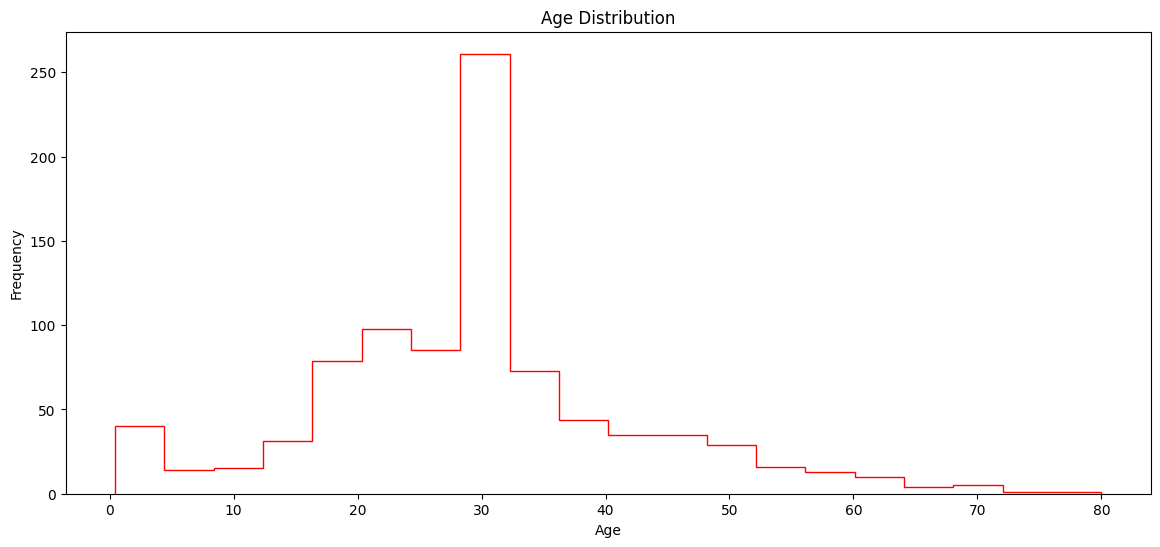

In [76]:
plt.figure(figsize=(14,6))
plt.hist(df.Age,bins=20,color="red",histtype="step")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.title("Age Distribution")
plt.show()

In [77]:
df['Age Category']=pd.cut(df.Age,bins=[0,15,30,60,81],labels=['Teens','Youths',"Adults",'Senior Citizens'],include_lowest=True)

In [78]:
df[:2]

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Survived,Age Category
0,3,male,22.0,1,0,7.2500,S,0,Youths
1,1,female,38.0,1,0,71.2833,C,1,Adults


In [79]:
df=df.drop("Age",axis=1)

In [80]:
df[:2]


,Pclass,Sex,SibSp,Parch,Fare,Embarked,Survived,Age Category
0,3,male,1,0,7.2500,S,0,Youths
1,1,female,1,0,71.2833,C,1,Adults


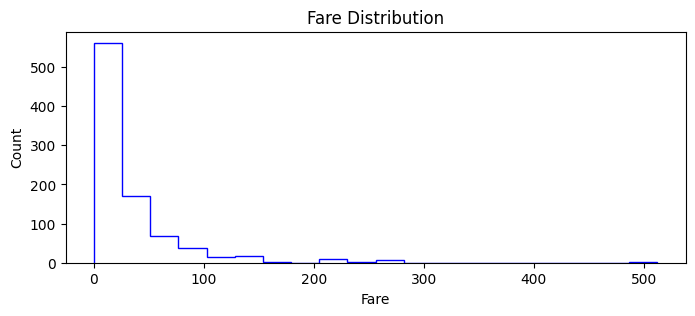

In [81]:
# Fare Columns
plt.figure(figsize=(8,3))
plt.hist(df.Fare,bins=20,color="Blue",histtype="step")
plt.xlabel("Fare")
plt.ylabel("Count")
plt.title("Fare Distribution")
plt.show()

In [82]:
df['Fare Category']=pd.cut(df.Fare,bins=[0,100,200,400,520],labels=['Low','Medium',"High",'Expensive'],include_lowest=True)


In [83]:
df[:2]

,Pclass,Sex,SibSp,Parch,Fare,Embarked,Survived,Age Category,Fare Category
0,3,male,1,0,7.2500,S,0,Youths,Low
1,1,female,1,0,71.2833,C,1,Adults,Low


In [84]:
df=df.drop("Fare",axis=1)
df.sample(3)

,Pclass,Sex,SibSp,Parch,Embarked,Survived,Age Category,Fare Category
561,3,male,0,0,S,0,Adults,Low
484,1,male,1,0,C,1,Youths,Low
371,3,male,1,0,S,0,Youths,Low


In [85]:
# analysing SibSp
df.SibSp.min(), df.SibSp.max() 

(np.int64(0), np.int64(8))

In [86]:
# analysing Parch
df.Parch.min(), df.Parch.max() 

(np.int64(0), np.int64(6))

In [87]:
df["Family Members"]=df.Parch+df.SibSp

In [88]:
df.drop(columns=["SibSp","Parch"],inplace=True)

In [89]:
df['Family']=df["Family Members"].apply(lambda x:'No' if x==0 else 'Yes')

In [90]:
df.sample(10)

,Pclass,Sex,Embarked,Survived,Age Category,Fare Category,Family Members,Family
742,1,female,C,1,Youths,High,4,Yes
35,1,male,S,0,Adults,Low,1,Yes
205,3,female,S,0,Teens,Low,1,Yes
207,3,male,C,1,Youths,Low,0,No
549,2,male,S,1,Teens,Low,2,Yes
397,2,male,S,0,Adults,Low,0,No
884,3,male,S,0,Youths,Low,0,No
561,3,male,S,0,Adults,Low,0,No
500,3,male,S,0,Youths,Low,0,No
863,3,female,S,0,Youths,Low,10,Yes


---


---

[<BarContainer object of 2 artists>, <BarContainer object of 2 artists>]


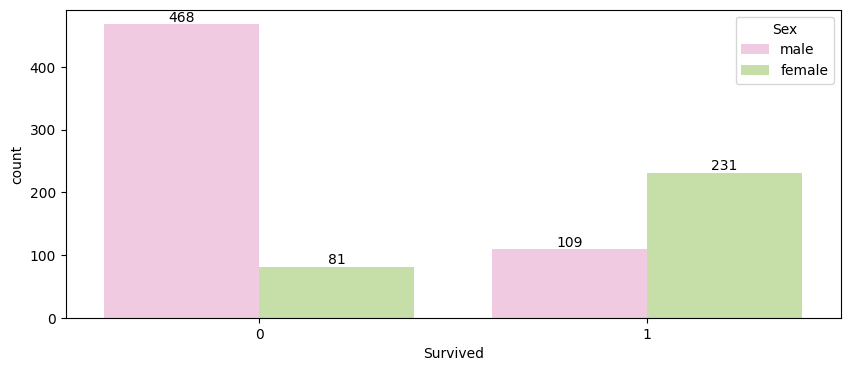

In [91]:
# analyse the distribution
plt.figure(figsize=(10,4))
a=sns.countplot(data=df,x="Survived",hue="Sex",palette="PiYG")
print(a.containers)
for container in a.containers:
    a.bar_label(container)
plt.show()

[<BarContainer object of 3 artists>, <BarContainer object of 4 artists>]


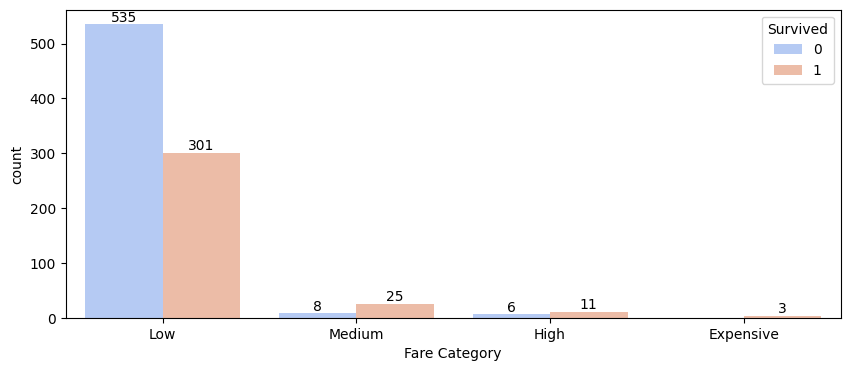

In [92]:
plt.figure(figsize=(10,4))
a=sns.countplot(data=df,x="Fare Category",hue="Survived",palette="coolwarm")
print(a.containers)
for container in a.containers:
    a.bar_label(container)
plt.show()

In [93]:
df['Family'].value_counts()

Family
No     535
Yes    354
Name: count, dtype: int64

---

---

In [94]:
# Seprating X & Y
x=df.drop(["Survived","Family Members"],axis=1)
y=df.Survived

In [95]:
x[:1]
y[:2]

0    0
1    1
Name: Survived, dtype: int64

In [96]:
x.shape

(889, 6)

In [97]:
y.shape

(889,)

In [98]:
#label Encoding 
from sklearn.preprocessing import LabelEncoder 

In [99]:
x.dtypes

Pclass              int64
Sex                object
Embarked           object
Age Category     category
Fare Category    category
Family             object
dtype: object

In [100]:
le=LabelEncoder()

In [101]:
#Apply 
for col in x.select_dtypes(include=['object','category']).columns:
    x[col]=le.fit_transform(x[col])

In [102]:
x["Family"].value_counts()

Family
0    535
1    354
Name: count, dtype: int64

In [103]:
x.dtypes

Pclass           int64
Sex              int64
Embarked         int64
Age Category     int64
Fare Category    int64
Family           int64
dtype: object

In [104]:
y.dtypes

dtype('int64')

In [105]:
x.head()

,Pclass,Sex,Embarked,Age Category,Fare Category,Family
0,3,1,2,3,2,1
1,1,0,0,0,2,1
2,3,0,2,3,2,0
3,1,0,2,0,2,1
4,3,1,2,0,2,0


---

In [106]:
#train_test Split
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [107]:
x_train.shape,x_test.shape,y_train.shape,y_test.shape

((711, 6), (178, 6), (711,), (178,))

In [108]:
#decision Tree 
from sklearn.tree import DecisionTreeClassifier

In [109]:
tree=DecisionTreeClassifier()

In [110]:
tree.fit(x_train,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [111]:
#train accuracy
tree.score(x_train,y_train)

0.8410689170182841

In [112]:
# test accuracy
tree.score(x_test,y_test)

0.8202247191011236

In [113]:
# confusion metrics
from sklearn.metrics import confusion_matrix 

In [114]:
y_pred=tree.predict(x_test)

In [115]:
cm=confusion_matrix(y_test,y_pred )

In [116]:
cm

array([[99, 10],
       [22, 47]])

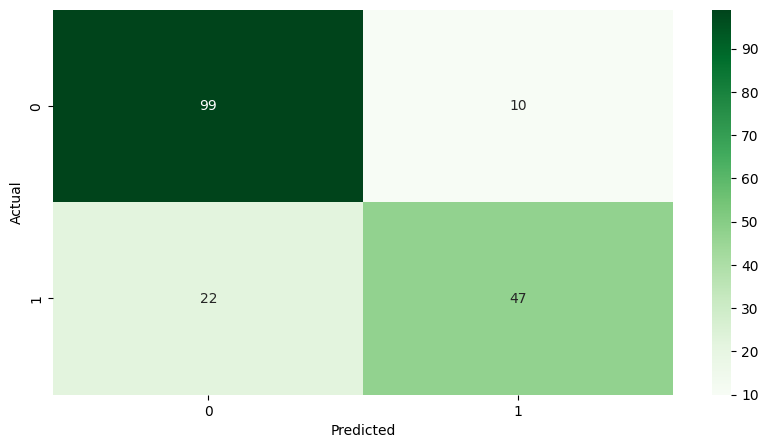

In [117]:
plt.figure(figsize=(10,5))
sns.heatmap(cm,annot=True,cmap="Greens")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [118]:
#classification Report
from sklearn.metrics import classification_report

In [119]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.82      0.91      0.86       109
           1       0.82      0.68      0.75        69

    accuracy                           0.82       178
   macro avg       0.82      0.79      0.80       178
weighted avg       0.82      0.82      0.82       178



In [120]:
# pip install joblib

In [121]:
from joblib import dump


In [122]:
# model
dump(tree,'tree.joblib')

['tree.joblib']

In [123]:
dump(x.columns,'columns.joblib')

['columns.joblib']

In [124]:
dump(x,'data.joblib')

['data.joblib']

In [125]:
pwd()

'C:\\Users\\VICTUS\\alpha It\\StreamLit'